## 1. 데이터 체크
데이터의 구조와 내용을 대략적으로 파악한다.

In [1]:
import pandas as pd

df = pd.read_json("hf://datasets/wmcnicho/StudyChat/data.jsonl", lines=True)

/Users/kimdaehoon/Test_Analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


데이터의 타입과 컬럼에 대해 확인한다

In [2]:
df.shape

(16851, 13)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16851 entries, 0 to 16850
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   prompt                     16851 non-null  str           
 1   response                   16851 non-null  str           
 2   topic                      16851 non-null  str           
 3   messages                   16851 non-null  object        
 4   timestamp                  16851 non-null  datetime64[ms]
 5   chatId                     16851 non-null  str           
 6   userId                     16851 non-null  str           
 7   interactionCount           16851 non-null  int64         
 8   chatTitle                  16851 non-null  str           
 9   chatStartTime              16851 non-null  str           
 10  chatTotalInteractionCount  16851 non-null  int64         
 11  llm_label                  16851 non-null  object        
 12  semester       

In [4]:
df.head()

,prompt,response,topic,messages,timestamp,chatId,userId,interactionCount,chatTitle,chatStartTime,chatTotalInteractionCount,llm_label,semester
0,"cross validation tests it on multiple sets, so...","Yes, cross-validation randomly splits your dat...",a4,"[{'content': 'You are a helpful assistant.', '...",2024-10-17 01:35:16.365,58ee2342-6f95-460f-9323-3f4d422d5bc8,011bd560-70e1-7036-62a9-3d29afd5179d,6,The R-squared score,2024-10-16T18:09:18.602392,17,"{'label': 'contextual_questions>Other', 'justi...",f24
1,### Report on findings/significance for Polyno...,### Report on Findings/Significance for Polyno...,a4,"[{'content': 'You are a helpful assistant.', '...",2024-10-17 04:46:37.817,58ee2342-6f95-460f-9323-3f4d422d5bc8,011bd560-70e1-7036-62a9-3d29afd5179d,12,The R-squared score,2024-10-16T18:09:18.602392,17,"{'label': 'writing_request>Write English', 'ju...",f24
2,what is KCL or KCI,KCl and KCI refer to the same chemical compoun...,a4,"[{'content': 'You are a helpful assistant.', '...",2024-10-17 04:53:39.803,58ee2342-6f95-460f-9323-3f4d422d5bc8,011bd560-70e1-7036-62a9-3d29afd5179d,13,The R-squared score,2024-10-16T18:09:18.602392,17,{'label': 'conceptual_questions>Other Concept'...,f24
3,rmse_poly = root_mean_squared_error(y_test_pol...,Certainly! Let’s break down the code snippet y...,a4,"[{'content': 'You are a helpful assistant.', '...",2024-10-17 03:41:42.322,58ee2342-6f95-460f-9323-3f4d422d5bc8,011bd560-70e1-7036-62a9-3d29afd5179d,7,The R-squared score,2024-10-16T18:09:18.602392,17,{'label': 'contextual_questions>Code Explanati...,f24
4,The R-squared score represents the proportion ...,"Certainly! The R-squared score, often denoted ...",a4,"[{'role': 'system', 'content': 'You are a help...",2024-10-16 22:09:38.513,58ee2342-6f95-460f-9323-3f4d422d5bc8,011bd560-70e1-7036-62a9-3d29afd5179d,0,The R-squared score,2024-10-16T18:09:18.602392,17,{'label': 'contextual_questions>Assignment Cla...,f24


In [5]:
df.isnull()

,prompt,response,topic,messages,timestamp,chatId,userId,interactionCount,chatTitle,chatStartTime,chatTotalInteractionCount,llm_label,semester
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16846,False,False,False,False,False,False,False,False,False,False,False,False,False
16847,False,False,False,False,False,False,False,False,False,False,False,False,False
16848,False,False,False,False,False,False,False,False,False,False,False,False,False
16849,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
from pprint import pprint

pprint(df.loc[0, "messages"])

[{'content': 'You are a helpful assistant.', 'role': 'system'},
 {'content': 'The R-squared score represents the proportion of the variance in '
             'the dependent variable (Size nm³) that is predictable from the '
             'independent variables (Temperature and Mols KCl). An R-squared '
             'score of 1 indicates perfect prediction, while a score of 0 '
             'indicates that the model does not explain any of the variability '
             'in the target variable\n'
             'explain this',
  'role': 'user'},
 {'content': 'Certainly! The R-squared score, often denoted as \\( R^2 \\), is '
             'a statistical measure used in the context of regression models. '
             'It provides insight into how well the independent variables '
             '(predictors) explain the variability or variation of the '
             'dependent variable (outcome). Here’s a breakdown of the key '
             'concepts involved:\n'
             '\n'
            

In [7]:
pprint(df.loc[0, "llm_label"])

{'justification': 'The user is asking a specific question about how cross '
                  'validation works, particularly whether it involves randomly '
                  'selecting data from their dataset. This is a contextual '
                  'question about the process described in the assignment.',
 'label': 'contextual_questions>Other'}


## 컬럼 요약

- `prompt`: 해당 interaction에서 사용자가 작성한 마지막 프롬프트 메시지
- `response`: 해당 prompt에 대해 AI Assistant가 생성한 응답
- `topic`: 과제 또는 주제를 나타내는 식별자 (`a1` ~ `a7`)
- `messages`: 해당 interaction 시점까지의 전체 메시지 히스토리
  - system, user, assistant 메시지를 포함하는 중첩 구조
- `timestamp`: 사용자가 해당 prompt를 전송한 시각
- `chatId`: conversation의 고유 식별자
- `userId`: 익명화된 사용자의 고유 식별자
- `interactionCount`: 해당 conversation 내 interaction의 순번
- `chatTitle`: conversation의 제목
- `chatStartTime`: 해당 conversation에서 첫 번째 user request가 발생한 시각
- `chatTotalInteractionCount`: 해당 conversation의 전체 interaction 수
- `llm_label`: 사용자 메시지의 dialogue act / intent를 LLM이 분류한 결과
- `semester`: 데이터가 수집된 학기 (`f24`, `s25`)

### 결측치를 확인

In [8]:
df.isnull().sum()

prompt                       0
response                     0
topic                        0
messages                     0
timestamp                    0
chatId                       0
userId                       0
interactionCount             0
chatTitle                    0
chatStartTime                0
chatTotalInteractionCount    0
llm_label                    0
semester                     0
dtype: int64

In [9]:
print("users:", df["userId"].nunique())
print("chats:", df["chatId"].nunique())
print("interactions:", len(df))

users: 203
chats: 2214
interactions: 16851


In [10]:
df.duplicated(
    subset=["chatId", "interactionCount"]
).sum()

np.int64(0)

In [11]:
chat_user_count = (
    df.groupby("chatId")["userId"]
    .nunique()
)

(chat_user_count > 1).sum()

np.int64(0)

In [12]:
df["timestamp"].min(), df["timestamp"].max()

(Timestamp('2024-09-03 19:48:07.971000'),
 Timestamp('2025-05-07 08:59:04.658000'))

In [13]:
chat_start = pd.to_datetime(
    df["chatStartTime"],
    errors="coerce"
)

chat_start.min(), chat_start.max()

(Timestamp('2024-09-03 15:48:07.616383'),
 Timestamp('2025-05-06 03:37:12.086020'))

In [14]:
df["semester"].value_counts()

semester
s25    9987
f24    6864
Name: count, dtype: int64

## 분석 시작

In [15]:
from src.preprocessing import build_interaction_dataset

from src.metrics import (
    build_conversation_dataset,
    build_user_dataset,
    summarize_numeric,
)

In [16]:
interaction_df = build_interaction_dataset(df)

conversation_df = build_conversation_dataset(
    interaction_df
)

user_df = build_user_dataset(
    interaction_df,
    conversation_df
)

In [17]:
print(f"interaction_df : {interaction_df.shape}")
print(f"conversation_df: {conversation_df.shape}")
print(f"user_df        : {user_df.shape}")

interaction_df : (16851, 23)
conversation_df: (2214, 15)
user_df        : (203, 19)


## Q1. 사용자는 AI Assistant를 어떻게 사용하고 있는가?

사용자는 여러 대화에서 질문과 응답을 주고받으며 AI Assistant를 이용한다. Q1에서는 사용자별 이용량, 한 대화의 진행 방식, 이용 시각, 질문 의도를 차례로 살펴본다.

분석 대상은 사용자 203명, 대화 2,214개, 관측 상호작용 16,851회이다. 대화는 `chatId`, 사용자는 `userId`로 구분하며, 활동일은 `timestamp`의 날짜별 이용 기록을 기준으로 계산한다.

**분석 순서:** 전체 규모 → 사용자별 이용량 → 대화의 길이와 활동일 → 시간대별 사용량 → 질문 의도.

In [18]:
overall = pd.Series({
    "users": user_df["userId"].nunique(),
    "conversations": conversation_df["chatId"].nunique(),
    "interactions": len(interaction_df),
})

overall

users              203
conversations     2214
interactions     16851
dtype: int64

In [19]:
user_metrics = {
    "대화 수": user_df["conversation_count"],
    "상호작용 수": user_df["interaction_count"],
    "활동일 수": user_df["active_days"],
}

user_summary = pd.DataFrame({
    name: summarize_numeric(series)
    for name, series in user_metrics.items()
}).T

user_summary

,count,mean,median,min,p25,p75,max
대화 수,203.0,10.906404,9.0,1.0,5.0,13.5,50.0
상호작용 수,203.0,83.009852,67.0,1.0,20.0,110.0,388.0
활동일 수,203.0,9.793103,9.0,1.0,5.0,14.0,32.0


### 사용자별 이용 수준

사용자는 중앙값 기준 9개 대화에서 67회 상호작용하고, 9개의 날짜에 서비스를 이용한다. 사용자당 평균 대화 수는 10.91개, 평균 상호작용 수는 83.01회, 평균 활동일 수는 9.79일이다.

상호작용 수의 P25는 20회, P75는 110회이며 최댓값은 388회이다. 이용량이 적은 사용자부터 많은 질문을 이어가는 사용자까지 폭넓게 분포한다. 이어지는 그래프에서 이러한 이용량 차이가 어떤 분포로 나타나는지 살펴본다.

In [20]:
conversation_rates = pd.Series({
    "multi_turn_rate": conversation_df["is_multi_turn"].mean(),
    "multi_day_rate": conversation_df["is_multi_day"].mean(),
})

(conversation_rates * 100).round(2)

multi_turn_rate    78.00
multi_day_rate     20.01
dtype: float64

### 대화 지표의 기준 설정

다음 표와 검사는 원본 `chatTotalInteractionCount`와 대화별 관측 기록을 비교하는 과정이다. Q1의 최종 대화 길이는 `observed_interaction_count`, 즉 같은 `chatId`에서 관측된 행 수로 계산한다.

In [21]:
conversation_metrics = {
    "상호작용 수": conversation_df["chatTotalInteractionCount"],
    "활동일 수": conversation_df["active_days"],
    "사용 기간(분)": conversation_df["conversation_span_minutes"],
}

conversation_summary = pd.DataFrame({
    name: summarize_numeric(series)
    for name, series in conversation_metrics.items()
}).T

conversation_summary

,count,mean,median,min,p25,p75,max
상호작용 수,2214.0,6.906052,3.000000,0.0,1.000000,9.000000,103.00000
활동일 수,2214.0,1.273713,1.000000,1.0,1.000000,1.000000,6.00000
사용 기간(분),2214.0,666.382851,17.686075,0.0,0.590017,188.914725,21516.23325


상호작용 수에 관련한 데이터 품질 문제 발견

In [22]:
interaction_check = (
    interaction_df.groupby("chatId")
    .agg(
        observed_count=("interactionCount", "size"),
        min_index=("interactionCount", "min"),
        max_index=("interactionCount", "max"),
        reported_total=("chatTotalInteractionCount", "first"),
    )
)

interaction_check["observed_eq_reported"] = (
    interaction_check["observed_count"]
    == interaction_check["reported_total"]
)

interaction_check["max_eq_reported"] = (
    interaction_check["max_index"]
    == interaction_check["reported_total"]
)

interaction_check["observed_eq_reported_plus_1"] = (
    interaction_check["observed_count"]
    == interaction_check["reported_total"] + 1
)

interaction_check[
    [
        "observed_eq_reported",
        "max_eq_reported",
        "observed_eq_reported_plus_1",
    ]
].mean()

observed_eq_reported           0.081301
max_eq_reported                0.948961
observed_eq_reported_plus_1    0.857724
dtype: float64

In [23]:
interaction_check = (
    interaction_df.groupby("chatId")
    .agg(
        observed_count=("interactionCount", "size"),
        min_index=("interactionCount", "min"),
        max_index=("interactionCount", "max"),
        reported_total=("chatTotalInteractionCount", "first"),
    )
)

interaction_check["starts_at_zero"] = (
    interaction_check["min_index"] == 0
)

interaction_check["is_contiguous"] = (
    interaction_check["observed_count"]
    == interaction_check["max_index"] - interaction_check["min_index"] + 1
)

interaction_check[
    ["starts_at_zero", "is_contiguous"]
].mean()

starts_at_zero    0.991870
is_contiguous     0.902891
dtype: float64

In [24]:
interaction_check["missing_interactions"] = (
    interaction_check["max_index"]
    - interaction_check["min_index"]
    + 1
    - interaction_check["observed_count"]
)

interaction_check["missing_interactions"].value_counts().sort_index()

missing_interactions
0     1999
1      123
2       45
3       21
4        5
5        7
6        6
7        1
8        4
9        1
20       1
21       1
Name: count, dtype: int64

In [25]:
total_consistency = (
    interaction_df.groupby("chatId")["chatTotalInteractionCount"]
    .nunique()
)

total_consistency.value_counts()

chatTotalInteractionCount
1    2214
Name: count, dtype: int64

In [26]:
problem = interaction_check[
    interaction_check["max_index"]
    != interaction_check["reported_total"]
]

problem.head(20)

,observed_count,min_index,max_index,reported_total,starts_at_zero,is_contiguous,missing_interactions
chatId,,,,,,,
006b74d1-d88c-43ce-8e22-e27ac270a79d,8,0,7,8,True,True,0
0177dd10-bfb9-4908-ba2f-f40d89e6aaa6,14,0,13,15,True,True,0
0504fd83-3115-4455-ab83-bb6aebf38c89,6,0,6,8,True,False,1
05eb476d-7260-40cd-9b5c-db1f5e05041c,9,0,8,9,True,True,0
06300b35-f818-4139-aa4f-dd5d0fb850e4,23,0,22,24,True,True,0
0bd18e40-ee3d-42c9-8f0d-86429d0d23de,10,0,9,10,True,True,0
0c733945-9960-4060-a83b-c164f9237363,2,0,1,2,True,True,0
0dae1cf5-54c4-4f99-886f-849508a6643b,3,0,3,4,True,False,1
0f93ee2f-a336-4fcf-a5c4-7ec0514bbfd1,6,1,6,7,False,True,0


In [27]:
valid_chat_ids = interaction_check[
    interaction_check["starts_at_zero"]
    & interaction_check["is_contiguous"]
].index

order_check = (
    interaction_df[
        interaction_df["chatId"].isin(valid_chat_ids)
    ]
    .sort_values(["chatId", "timestamp"])
    .groupby("chatId")["interactionCount"]
    .apply(lambda x: x.is_monotonic_increasing)
)

order_check.value_counts()

interactionCount
True    1983
Name: count, dtype: int64

### 관측 기록을 기준으로 대화 구성

원본 총량과 관측 행 수가 일치하는 대화는 8.13%이고, 원본 순번의 최댓값과 총량이 일치하는 대화는 94.90%이다. 대화 215개에서는 관측된 최소·최대 순번 사이에 공백이 확인되었다.

분석용 대화는 `chatId`별 관측 행 수를 집계하고, `timestamp` 순서에 따라 관측 순번을 부여해 구성한다. 원본 순번과 총량은 비교용으로 보존한다. 이후의 첫 질문과 대화 길이는 이 관측 기준을 따른다.

In [28]:
interaction_df[
    [
        "chatId",
        "timestamp",
        "interactionCount",
        "observed_interaction_index",
    ]
].head(20)

,chatId,timestamp,interactionCount,observed_interaction_index
11179,0002a060-8fd4-40ae-b17e-0e1a713d31d4,2025-04-04 00:28:40.349,0,0
4705,00078d7c-022c-429b-9e07-33459b7a5f6e,2024-09-19 03:03:52.371,0,0
4706,00078d7c-022c-429b-9e07-33459b7a5f6e,2024-09-19 05:53:01.336,1,1
4707,00078d7c-022c-429b-9e07-33459b7a5f6e,2024-09-19 05:53:51.302,2,2
4708,00078d7c-022c-429b-9e07-33459b7a5f6e,2024-09-19 06:04:32.594,3,3
6802,000c7c9c-0e5f-41dd-87d7-60c397624745,2024-09-23 07:05:04.365,0,0
13812,00615743-5427-4ec2-829c-8523d2d2552b,2025-03-07 07:23:24.290,0,0
13813,00615743-5427-4ec2-829c-8523d2d2552b,2025-03-07 07:24:00.168,1,1
1691,006b74d1-d88c-43ce-8e22-e27ac270a79d,2024-12-05 01:35:33.669,0,0
1692,006b74d1-d88c-43ce-8e22-e27ac270a79d,2024-12-05 01:40:39.904,1,1


In [29]:
index_check = (
    interaction_df
    .groupby("chatId")["observed_interaction_index"]
    .apply(lambda x: list(x) == list(range(len(x))))
)

index_check.value_counts()

observed_interaction_index
True    2214
Name: count, dtype: int64

In [30]:
conversation_df = build_conversation_dataset(
    interaction_df
)

user_df = build_user_dataset(
    interaction_df,
    conversation_df
)

In [32]:
summarize_numeric(
    conversation_df["observed_interaction_count"]
)

count     2214.000000
mean         7.611111
median       4.000000
min          1.000000
p25          2.000000
p75         10.000000
max        103.000000
dtype: float64

In [33]:
pd.crosstab(
    conversation_df["is_multi_turn"],
    conversation_df["is_multi_day"],
)

is_multi_day,False,True
is_multi_turn,,
False,487,0
True,1284,443


In [34]:
conversation_metrics = {
    "상호작용 수": conversation_df["observed_interaction_count"],
    "활동일 수": conversation_df["active_days"],
    "사용 기간(분)": conversation_df["conversation_span_minutes"],
}

conversation_summary = pd.DataFrame({
    name: summarize_numeric(series)
    for name, series in conversation_metrics.items()
}).T

conversation_summary

,count,mean,median,min,p25,p75,max
상호작용 수,2214.0,7.611111,4.000000,1.0,2.000000,10.000000,103.00000
활동일 수,2214.0,1.273713,1.000000,1.0,1.000000,1.000000,6.00000
사용 기간(분),2214.0,666.382851,17.686075,0.0,0.590017,188.914725,21516.23325


### 한 대화에서 이어지는 이용

사용자는 대화 하나에서 중앙값 4회, 평균 7.61회 상호작용한다. 관측 상호작용 수의 P25는 2회, P75는 10회이며, 가장 긴 대화에서는 103회가 관측된다.

대화 활동일의 중앙값과 P75는 모두 1일이다. 한 날짜에 이용되는 대화가 큰 비중을 차지하며, 일부 대화에서는 여러 날짜에 걸친 이용이 나타난다.

첫·마지막 관측 사이 경과 시간은 중앙값 17.69분, 평균 666.38분이다. 이 지표는 중간 공백을 포함한 대화의 시간 범위를 보여준다.

원본 interaction 순번 및 총 interaction 관련 메타데이터에서 일부 불일치가 확인되어, 대화 길이와 Multi-turn 여부는 현재 데이터에서 관측된 interaction을 기준으로 재계산하였다.

In [51]:
import matplotlib.pyplot as plt


def plot_count_distribution(series, title, xlabel, ylabel):
    data = series.dropna()

    distribution = (
        data.value_counts()
        .sort_index()
    )

    plt.figure(figsize=(9, 4))

    plt.bar(
        distribution.index,
        distribution.values,
        color="steelblue",
        alpha=0.8
    )

    # Mean
    plt.axvline(
        data.mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {data.mean():.1f}"
    )

    # Median
    plt.axvline(
        data.median(),
        color="black",
        linestyle=":",
        linewidth=2,
        label=f"Median: {data.median():.1f}"
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.legend()
    plt.tight_layout()

    plt.show()

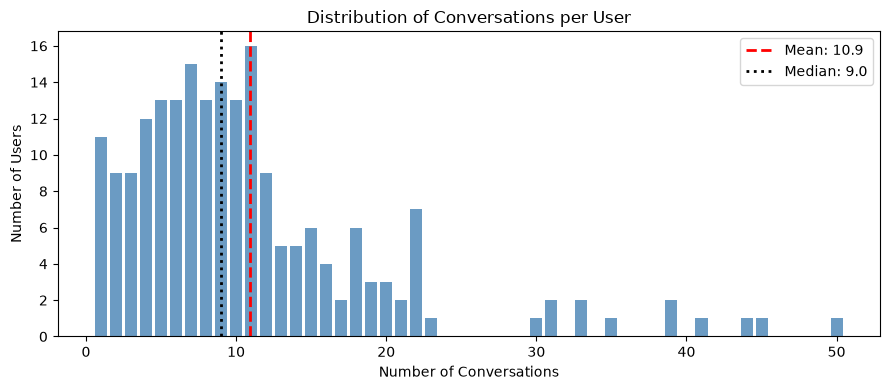

In [52]:
plot_count_distribution(
    user_df["conversation_count"],
    "Distribution of Conversations per User",
    "Number of Conversations",
    "Number of Users"
)

In [58]:
def plot_histogram(series, title, xlabel, ylabel, bins=30):
    data = series.dropna()

    plt.figure(figsize=(9, 4))

    plt.hist(
        data,
        bins=bins,
        color="steelblue",
        alpha=0.8
    )

    plt.axvline(
        data.mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {data.mean():.1f}"
    )

    plt.axvline(
        data.median(),
        color="black",
        linestyle=":",
        linewidth=2,
        label=f"Median: {data.median():.1f}"
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()

    plt.show()

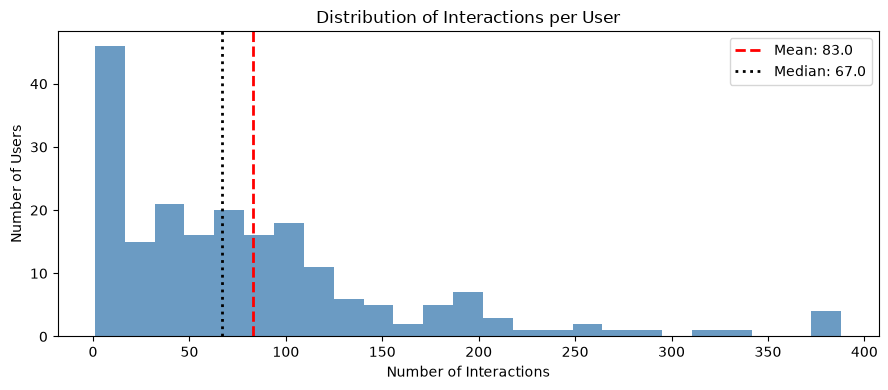

In [59]:
plot_histogram(
    user_df["interaction_count"],
    "Distribution of Interactions per User",
    "Number of Interactions",
    "Number of Users",
    bins=25
)

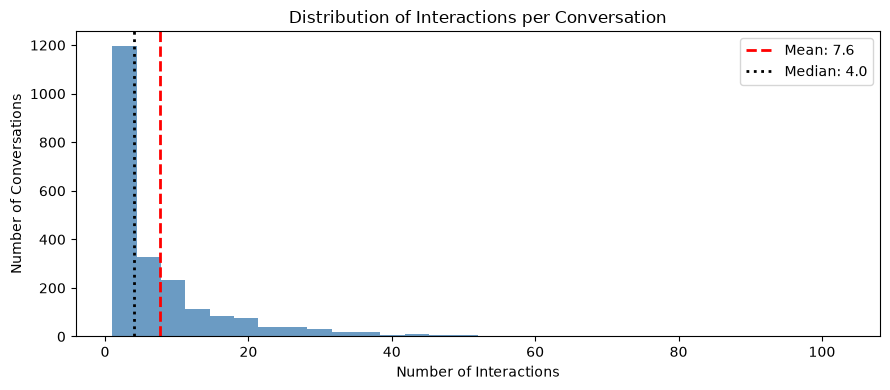

In [60]:
plot_histogram(
    conversation_df["observed_interaction_count"],
    "Distribution of Interactions per Conversation",
    "Number of Interactions",
    "Number of Conversations",
    bins=30
)

### 이용량 분포

사용자별 대화 수와 상호작용 수는 낮은 이용량 구간에 관측값이 모이고 높은 이용량 방향으로 꼬리가 이어진다. 특히 사용자당 상호작용 수는 중앙값 67회에서 최대 388회까지 분포하여 이용 강도의 차이가 나타난다.

대화별 상호작용도 짧게 이어지는 대화와 길게 이어지는 대화가 함께 존재한다. 다음 단계에서는 대화가 여러 번 이어지는 비율과 여러 날짜에 걸쳐 사용되는 비율을 확인한다.

In [61]:
conversation_rates = pd.Series({
    "Multi-turn Rate": conversation_df["is_multi_turn"].mean(),
    "Multi-day Rate": conversation_df["is_multi_day"].mean(),
})

(conversation_rates * 100).round(2)

Multi-turn Rate    78.00
Multi-day Rate     20.01
dtype: float64

### 대화를 사용하는 세 가지 패턴

| 대화 이용 패턴 | 대화 수 | 전체 대화 중 비율 |
|---|---:|---:|
| 한 번의 상호작용이 관측된 대화 | 487 | 22.00% |
| 같은 날짜에 여러 번 상호작용한 대화 | 1,284 | 57.99% |
| 여러 날짜에 걸쳐 상호작용한 대화 | 443 | 20.01% |

사용자는 같은 날 후속 질문을 이어가는 대화를 가장 많이 보인다. 한 번의 질문으로 관측이 끝난 대화와 날짜를 바꾸어 같은 대화를 다시 이용하는 패턴도 함께 나타난다. 두 번 이상 상호작용한 대화를 합치면 전체의 78.00%이다.

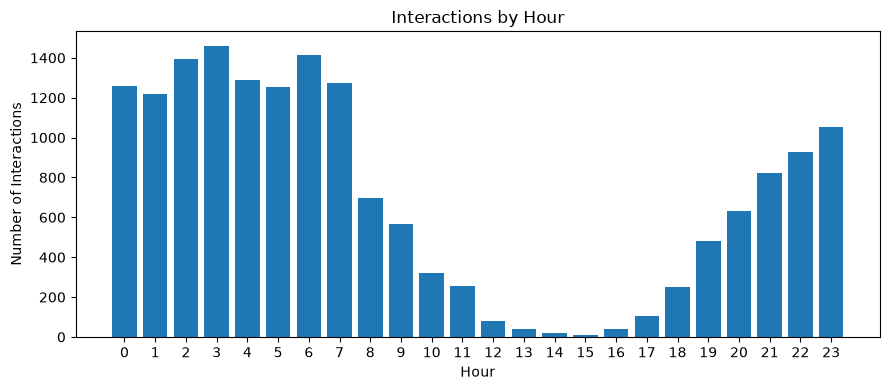

In [62]:
hourly_usage = (
    interaction_df["interaction_hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 4))
plt.bar(
    hourly_usage.index,
    hourly_usage.values
)

plt.title("Interactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Interactions")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

### 이용 시간대와 시간대 기준

전체 상호작용은 기록 시각 기준 0~7시에 집중되고, 12~16시에는 매우 낮은 이용량을 보인 뒤 17시 이후 다시 증가하는 패턴을 보인다.

다만 현재 `interaction_hour`는 원본 `timestamp`의 시각을 그대로 사용하고 있으며 별도의 timezone 변환이 적용되지 않았다. 이 때문에 0~7시의 높은 사용량과 낮 시간대의 급격한 감소가 실제 사용자의 생활 시간과 어긋나 보이는 패턴으로 나타난 것으로 판단된다.

원본 timestamp가 UTC 기준으로 기록된 가능성을 고려하면, 현지 시간으로 변환했을 때 현재의 0~7시 구간은 저녁~심야 이용에 해당할 수 있다.

In [63]:
intent_distribution = (
    interaction_df["intent_category"]
    .value_counts()
)

intent_distribution

intent_category
conceptual_questions    5199
writing_request         4336
provide_context         3028
contextual_questions    2938
verification             647
editing_request          418
off_topic                250
misc                      35
Name: count, dtype: int64

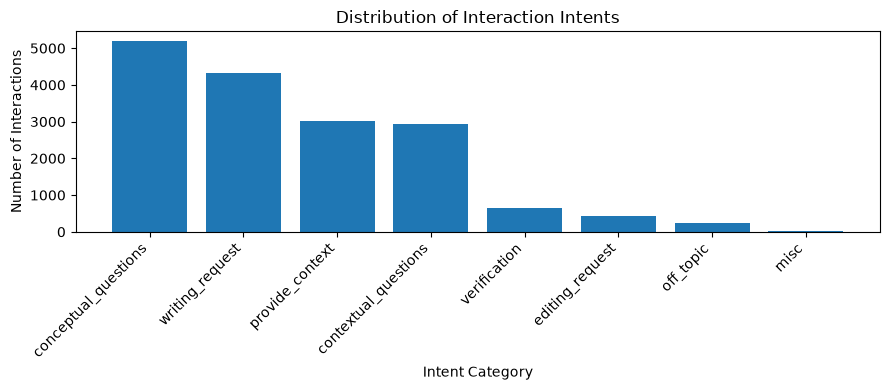

In [64]:
plt.figure(figsize=(9, 4))

plt.bar(
    intent_distribution.index,
    intent_distribution.values
)

plt.title("Distribution of Interaction Intents")
plt.xlabel("Intent Category")
plt.ylabel("Number of Interactions")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 사용 목적과 Q1의 핵심 발견

사용자는 개념을 질문하고 작성 작업을 요청하며, 관련 문맥을 제공하거나 그 문맥에 대한 질문을 이어간다. 전체 상호작용의 LLM 의도 분류에서 개념 질문은 30.85%, 작성 요청은 25.73%, 문맥 제공은 17.97%, 문맥 기반 질문은 17.44%를 차지한다.

**Q1 핵심 발견**

1. 사용자당 이용량은 중앙값 9개 대화·67회 상호작용이며, 높은 이용량을 보이는 사용자까지 폭넓게 분포한다.
2. 대화의 57.99%는 같은 날짜에 여러 번 상호작용하고, 20.01%는 여러 날짜에 걸쳐 사용된다. 한 번의 상호작용이 관측된 대화는 22.00%이다.
3. 개념 질문과 작성 요청이 큰 비중을 차지한다. 이어지는 분석에서는 이러한 이용 목적이 사용자 재사용 및 대화 진행 방식과 어떻게 연결되는지 살펴본다.

Q2에서는 사용자 단위로 돌아가, 한 날짜에 활동한 사용자와 여러 날짜에 활동한 사용자의 첫 이용 행동을 비교한다.

## Q2. 지속 사용자와 일회성 사용자는 어떤 차이가 있는가?

**지속 사용자**는 관측 기간에 서로 다른 날짜에서 2일 이상 상호작용한 사용자로 정의한다. **일회성 사용자**는 관측 기간에 한 날짜에서만 상호작용한 사용자로 정의한다. 사용일은 `timestamp`의 날짜에 하나 이상의 상호작용이 기록된 날이다.

이 기준으로 지속 사용자 190명과 일회성 사용자 13명을 구분하고, 처음 어떤 방식으로 서비스를 이용했는지 비교한다.

| 순서 | 비교 내용 | 확인할 행동 |
|---|---|---|
| 1 | 집단별 사용자 수와 비율 | 한 날짜 이용과 여러 날짜 이용의 규모 |
| 2 | 총 대화 수·상호작용 수·활동일 수 | 관측 기간의 누적 이용량 |
| 3 | 첫 사용일의 대화 수·상호작용 수 | 처음 이용한 날의 사용 방식 |
| 4 | 첫 대화 전체 길이·다중 상호작용 비율 | 첫 대화를 이어가는 방식 |
| 5 | 첫 관측 질문의 길이·의도 | 처음 입력한 요청의 형태와 목적 |
| 6 | 두 번째 활동일까지의 간격 | 지속 사용자의 재사용 시점 |

In [65]:
q2_user_df = user_df.copy()

q2_user_df["user_type"] = (
    q2_user_df["is_returning"]
    .map({
        False: "One-day User",
        True: "Returning User",
    })
)

In [66]:
group_count = q2_user_df["user_type"].value_counts()

group_share = (
    q2_user_df["user_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(
    pd.DataFrame({
        "Users": group_count,
        "Share (%)": group_share,
    })
)

,Users,Share (%)
user_type,,
Returning User,190,93.6
One-day User,13,6.4


### 사용자 집단의 구성

지속 사용자는 190명(93.60%), 일회성 사용자는 13명(6.40%)이다. 현재 관측된 사용자 집단에서는 여러 날짜에 걸친 이용이 주된 패턴이다.

이후 비교에서는 각 집단의 사용자 수와 집단 내부의 비율을 함께 제시한다.

In [67]:
overall_comparison = (
    q2_user_df
    .groupby("user_type")
    .agg(
        users=("userId", "size"),

        mean_conversations=("conversation_count", "mean"),
        median_conversations=("conversation_count", "median"),

        mean_interactions=("interaction_count", "mean"),
        median_interactions=("interaction_count", "median"),

        mean_active_days=("active_days", "mean"),
        median_active_days=("active_days", "median"),
    )
    .round(2)
)

overall_comparison

,users,mean_conversations,median_conversations,mean_interactions,median_interactions,mean_active_days,median_active_days
user_type,,,,,,,
One-day User,13,1.46,1.0,4.77,4.0,1.00,1.0
Returning User,190,11.55,9.0,88.36,69.0,10.39,9.0


### 누적 이용량

지속 사용자는 평균 11.55개 대화에서 88.36회 상호작용하고 10.39개의 날짜에 활동한다. 일회성 사용자는 이용한 하루 동안 평균 1.46개 대화에서 4.77회 상호작용한다.

다음 비교에서는 두 집단의 첫 사용일에 초점을 맞춰, 처음 이용할 때 대화를 몇 개 만들고 얼마나 질문을 이어가는지 살펴본다.

In [68]:
initial_behavior = (
    q2_user_df
    .groupby("user_type")
    .agg(
        users=("userId", "size"),

        mean_first_day_conversations=(
            "first_day_conversation_count", "mean"
        ),
        median_first_day_conversations=(
            "first_day_conversation_count", "median"
        ),

        mean_first_day_interactions=(
            "first_day_interaction_count", "mean"
        ),
        median_first_day_interactions=(
            "first_day_interaction_count", "median"
        ),

        mean_first_chat_interactions=(
            "first_chat_interaction_count", "mean"
        ),
        median_first_chat_interactions=(
            "first_chat_interaction_count", "median"
        ),

        first_chat_multi_turn_rate=(
            "first_chat_is_multi_turn", "mean"
        ),

        mean_first_prompt_length=(
            "first_prompt_char_count", "mean"
        ),
        median_first_prompt_length=(
            "first_prompt_char_count", "median"
        ),
    )
)

initial_behavior["first_chat_multi_turn_rate"] *= 100

initial_behavior.round(2)

,users,mean_first_day_conversations,median_first_day_conversations,mean_first_day_interactions,median_first_day_interactions,mean_first_chat_interactions,median_first_chat_interactions,first_chat_multi_turn_rate,mean_first_prompt_length,median_first_prompt_length
user_type,,,,,,,,,,
One-day User,13,1.46,1.0,4.77,4.0,4.23,3.0,84.62,5335.85,2425.0
Returning User,190,1.31,1.0,5.84,3.0,6.67,3.0,78.95,909.16,230.0


### 첫 이용의 공통점과 요청 형태의 차이

두 집단 모두 첫날 대화 수 중앙값은 1개, 첫 대화 전체 상호작용 수 중앙값은 3회이다. 첫 대화에서 다중 상호작용이 나타난 비율은 일회성 사용자 84.62%, 지속 사용자 78.95%이다. 두 집단 모두 첫 대화에서 질문을 이어가는 이용이 흔하다.

첫날 상호작용 수는 일회성 사용자에서 평균 4.77회·중앙값 4회, 지속 사용자에서 평균 5.84회·중앙값 3회이다.

눈에 띄는 차이는 첫 관측 질문의 길이이다. 일회성 사용자의 중앙값은 2,425자, 지속 사용자는 230자이다. 첫날 대화 수와 첫 대화 길이의 중앙값은 같지만, 처음 입력하는 메시지의 길이에서 차이가 나타난다. 다음으로 질문 의도를 비교해 요청 목적을 살펴본다.

In [69]:
first_intent_count = pd.crosstab(
    q2_user_df["first_intent_category"],
    q2_user_df["user_type"],
)

first_intent_count

user_type,One-day User,Returning User
first_intent_category,,
conceptual_questions,1,38
contextual_questions,0,36
editing_request,0,11
off_topic,3,26
provide_context,1,20
verification,0,3
writing_request,8,56


In [70]:
first_intent_share = (
    pd.crosstab(
        q2_user_df["first_intent_category"],
        q2_user_df["user_type"],
        normalize="columns",
    )
    .mul(100)
    .round(2)
)

first_intent_share

user_type,One-day User,Returning User
first_intent_category,,
conceptual_questions,7.69,20.00
contextual_questions,0.00,18.95
editing_request,0.00,5.79
off_topic,23.08,13.68
provide_context,7.69,10.53
verification,0.00,1.58
writing_request,61.54,29.47


### 첫 질문의 목적

일회성 사용자 13명 중 8명(61.54%)은 작성 요청으로 처음 관측된다. 개념 질문은 1명(7.69%)이다.

지속 사용자 190명에서는 작성 요청 56명(29.47%), 개념 질문 38명(20.00%), 문맥 기반 질문 36명(18.95%) 등으로 첫 요청이 분산된다. 이러한 분포는 일부 사용자가 AI Assistant를 반복적인 대화 상대라기보다, 작성과 같은 특정 과업을 한 번에 맡겨 작업 부담을 줄이는 도구로 활용하는 경향이 있을 가능성을 보여준다.

일회성 사용자 집단에서는 긴 첫 메시지와 높은 작성 요청 비중이 각각 나타나고, 지속 사용자 집단에서는 여러 요청 유형이 비교적 고르게 나타난다. 추가 분석에서는 같은 사용자에게 긴 입력과 작성 요청이 함께 나타나는지 확인한다.

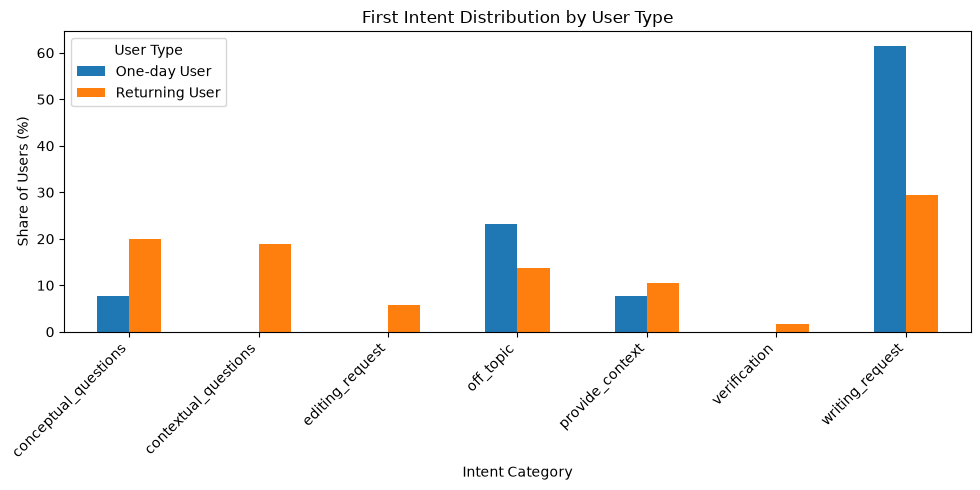

In [71]:
intent_plot = first_intent_share.copy()

intent_plot.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("First Intent Distribution by User Type")
plt.xlabel("Intent Category")
plt.ylabel("Share of Users (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="User Type")
plt.tight_layout()
plt.show()

In [72]:
one_day = q2_user_df.loc[
    ~q2_user_df["is_returning"],
    "first_day_interaction_count"
]

returning = q2_user_df.loc[
    q2_user_df["is_returning"],
    "first_day_interaction_count"
]

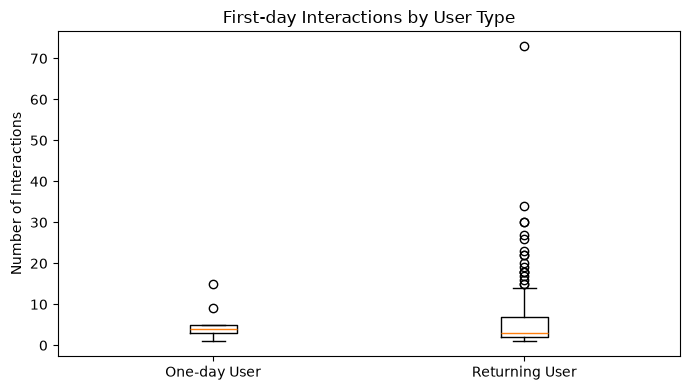

In [73]:
plt.figure(figsize=(7, 4))

plt.boxplot(
    [one_day, returning],
    tick_labels=["One-day User", "Returning User"],
    showfliers=True,
)

plt.title("First-day Interactions by User Type")
plt.ylabel("Number of Interactions")
plt.tight_layout()
plt.show()

In [74]:
return_interval = q2_user_df.loc[
    q2_user_df["is_returning"],
    "days_to_second_active_day"
]

summarize_numeric(return_interval)

count     190.000000
mean        8.621053
median      8.000000
min         1.000000
p25         1.000000
p75        13.000000
max        61.000000
dtype: float64

### 지속 사용자의 재사용 시점과 Q2의 핵심 발견

지속 사용자 190명의 첫 활동일에서 두 번째 활동일까지의 간격은 중앙값 8일, 평균 8.62일이다. P25는 1일, P75는 13일로, 빠르게 다시 이용하는 사용자와 더 긴 간격을 두고 이용하는 사용자가 함께 존재한다.

**Q2 핵심 발견**

1. 사용자 203명 중 190명은 여러 날짜에 서비스를 이용하고, 13명은 한 날짜에 이용한다.
2. 두 집단 모두 첫날 대화 수 중앙값은 1개이고 첫 대화 전체 길이 중앙값은 3회이다. 첫 대화에서 후속 질문을 이어가는 패턴은 두 집단에 공통적으로 나타난다.
3. 일회성 사용자는 첫 관측 질문이 더 길고 작성 요청 비중이 높다. 지속 사용자는 작성 요청·개념 질문·문맥 기반 질문 등 여러 목적으로 처음 이용한다.

Q3에서는 대화 단위로 분석 대상을 바꾸어, 첫 관측 질문의 목적과 길이가 후속 상호작용과 어떻게 연결되는지 확인한다.

## 이후 분석 방향: Q3 → 추가 질문 → Q4

### Q3. 어떤 대화가 후속 상호작용으로 이어지는가?

각 대화를 관측 상호작용 1회와 2회 이상으로 구분하고, 첫 관측 질문의 의도와 길이를 비교한다.

| 분석 순서 | 확인할 내용 |
|---|---|
| 1. 대화 유형의 구성 | 단일·다중 상호작용 대화 수와 비율 |
| 2. 첫 질문 의도 | 의도별 대화 수, 다중 상호작용 비율, 대화 길이 중앙값 |
| 3. 첫 질문 길이 | 단일·다중 대화의 길이 분포와 길이 구간별 후속 상호작용 비율 |
| 4. 보조 비교 | 필요 시 첫 AI 응답 길이 및 같은 의도 안에서의 질문 길이 차이 |

여기서 단일 관측 대화에 개념 질문이 많은지, 개념 질문 대화가 다른 의도보다 한 번의 상호작용으로 끝나는 비율이 높은지 확인하여 사전형 이용 가설을 검토한다.

### 추가 질문 5개

아래는 검증할 질문이다.

| 번호 | 질문 | 연결되는 사용자 행동 |
|---|---|---|
| 1 | 단일 관측 개념 질문 대화의 사용자는 이후 다른 채팅에서도 이용하는가? | 대화별로 필요한 내용을 질문하고 다시 이용하는 방식 |
| 2 | 일회성 사용자가 받은 첫 AI 응답은 물음표로 끝나는 비율이 더 낮은가? | 첫 응답 형식과 다른 날짜의 재사용 |
| 3 | 기록 시각 15시 전후의 낮은 이용량과 이후 증가는 여러 날짜·사용자에게 공통적인가? | 이용 시간의 집중과 사용자별 시간대 패턴 |
| 4 | 일회성 사용자의 긴 첫 질문은 작성 요청이나 긴 자료·코드 입력과 관련되는가? | 긴 초기 입력과 과업의 형태 |
| 5 | 두 번째 활동일에는 이전에 이용한 대화와 다른 대화 중 무엇을 이용하는가? | 기존 대화 재사용과 다른 대화로의 이용 확장 |